**Market Basket Analysis(Apriori Algorithm)**

Objective: To increase sell by

Finding the best ways to create promotions or apply discounts on particular items
Finding the pattern occuring to sales to apply promotions more accurately


In [6]:
# Import Libraries for association rule mininig to find frequent patterns
import pandas as pd
import numpy as np

# First, install the mlxtend package
!pip install mlxtend
from mlxtend.frequent_patterns import apriori, association_rules

# Importing Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns
import re
import networkx as nx

   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ------------------------------- -------- 1.0/1.4 MB 5.6 MB/s eta 0:00:01
   ---------------------------------------- 1.4/1.4 MB 5.0 MB/s eta 0:00:00


In [20]:
# read csv
df = pd.read_csv(r"C:\Users\shubh\OneDrive\Desktop\BANG2025\BANG2025\Machine Learning Projects\Untitled Folder\Analytics case study (market basket analysis ecommerce).csv", encoding = 'latin')

df.head()

,Product,Product Category (Enhanced Ecommerce),Transaction ID,Unique Purchases,Product Revenue
0,3.7V 3400mah LIION 12.6WH,Battery/Consumer Rechargeable,EC0043605902,47,"$1,597.53"
1,3V PHOTO LITHIUM,Battery/Primary Other,EC0043507670,47,"$1,246.44"
2,12V 11.2AH 225CCA AGM 12/0,Battery/Powersports,EC0043504182,41,"$4,714.59"
3,12V 12AH 165CCA FLOODED 6/0,Battery/Powersports,EC0043503186,39,"$2,456.61"
4,12V 12AH 210CCA AGM 12/0,Battery/Powersports,EC0043406547,34,"$3,570.00"


In [22]:
# show random 10 entries
df.sample(10)

,Product,Product Category (Enhanced Ecommerce),Transaction ID,Unique Purchases,Product Revenue
70639,6V GC2 ULTRA GOLF 12,Battery/Golf &amp; Scrubber,EC0042804822,1,$519.96
33721,12V 27F AGM DUAL PURPOSE 60,Battery/Auto/Light Truck,EC0042806016,1,$379.99
68091,4PK AA 2500MAH NIMH,Battery/Consumer Rechargeable,EC0044000995,1,$37.98
59313,24PK 1.5V AAA ALKALINE,Battery/Primary Common,EC0043509228,1,$18.99
13617,1.5V ALKALINE AA CONTRACTOR 24PK,Battery/Primary Common,EC0043608040,1,$11.99
13767,1.5V ALKALINE AA CONTRACTOR 24PK,Battery/Primary Common,EC0044000863,1,$5.76
20012,12V 12AH 200CCA AGM 12/0,Battery/Powersports,EC0043900057,1,$104.99
18104,12V 10AH 175CCA AGM 12/0,Battery/Powersports,EC0043706075,1,$99.99
91382,REMOTE DODGE/RAM,Device/Key Fob,EC0044007204,1,$139.99
34559,12V 27M DURACELL ULTRA AGM 30,Battery/Marine/RV,EC0043700948,1,$239.99


In [24]:
df.drop_duplicates()

,Product,Product Category (Enhanced Ecommerce),Transaction ID,Unique Purchases,Product Revenue
0,3.7V 3400mah LIION 12.6WH,Battery/Consumer Rechargeable,EC0043605902,47,"$1,597.53"
1,3V PHOTO LITHIUM,Battery/Primary Other,EC0043507670,47,"$1,246.44"
2,12V 11.2AH 225CCA AGM 12/0,Battery/Powersports,EC0043504182,41,"$4,714.59"
3,12V 12AH 165CCA FLOODED 6/0,Battery/Powersports,EC0043503186,39,"$2,456.61"
4,12V 12AH 210CCA AGM 12/0,Battery/Powersports,EC0043406547,34,"$3,570.00"
...,...,...,...,...,...
92245,ZUS SMART VEHICLE HEALTH MONITOR MINI,Bulb - Controls/Smart Home,EC0043404746,1,$9.97
92246,ZUS SMART VEHICLE HEALTH MONITOR MINI,Bulb - Controls/Smart Home,EC0043803104,1,$15.99
92247,ZUS SMART VEHICLE HEALTH MONITOR MINI,Bulb - Controls/Smart Home,EC0043804320,1,$15.99
92248,ZUS SMART VEHICLE HEALTH MONITOR MINI,Bulb - Controls/Smart Home,EC0044001978,1,$15.99


In [26]:
# Statistical analysis of data
df.describe()

,Unique Purchases
count,92250.000000
mean,1.164564
std,0.676474
min,1.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,47.000000


In [28]:
# Short Info of data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92250 entries, 0 to 92249
Data columns (total 5 columns):
 #   Column                                 Non-Null Count  Dtype 
---  ------                                 --------------  ----- 
 0   Product                                92250 non-null  object
 1   Product Category (Enhanced Ecommerce)  92250 non-null  object
 2   Transaction ID                         92250 non-null  object
 3   Unique Purchases                       92250 non-null  int64 
 4   Product Revenue                        92250 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.5+ MB


****EDA****

In [34]:
# Dropping all null values
df = df.dropna()

Taking the positive quantity values

In [37]:
df = df[df['Unique Purchases']>=0]
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92250 entries, 0 to 92249
Data columns (total 5 columns):
 #   Column                                 Non-Null Count  Dtype 
---  ------                                 --------------  ----- 
 0   Product                                92250 non-null  object
 1   Product Category (Enhanced Ecommerce)  92250 non-null  object
 2   Transaction ID                         92250 non-null  object
 3   Unique Purchases                       92250 non-null  int64 
 4   Product Revenue                        92250 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.5+ MB


**Dropping row where Transaction Id is missing**

In [42]:
df.drop(df[df['Transaction ID'] == '<transaction id>'].index, inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 92249 entries, 0 to 92249
Data columns (total 5 columns):
 #   Column                                 Non-Null Count  Dtype 
---  ------                                 --------------  ----- 
 0   Product                                92249 non-null  object
 1   Product Category (Enhanced Ecommerce)  92249 non-null  object
 2   Transaction ID                         92249 non-null  object
 3   Unique Purchases                       92249 non-null  int64 
 4   Product Revenue                        92249 non-null  object
dtypes: int64(1), object(4)
memory usage: 4.2+ MB


In [54]:
x = df['Product'].value_counts().sort_values(ascending=False)[:25]
x

Product
12V U1 L&amp;G 6                  2425
6V GC2 ULTRA GOLF 12              1684
AGM 12V 7AH .187 FASTON           1642
12V 18AH 310CCA AGM 12/0          1204
12V 31DT DURACELL ULTRA AGM 30    1118
AGM 12V 5AH .187 FASTON           1077
DC 12V 35AH J TERM                1005
12V 17.5AH 310 CCA                 996
1.5V IND AA ALK BULK               979
1.5V ALKAL                         977
12V 30AH 400 CCA                   940
12V U1R L&amp;G 6                  928
1.55V SVROX                        925
12V 27 MARINE DP 12                922
12V 24 MARINE DP 12                900
GRP 31 AGM DUAL X2 MARINE          816
12V 24F ULTRA GOLD 36              811
1.5V IND AAA ALK BULK              789
AGM 12V 12AH .250 FASTON           781
12V 65 ULTRA 24                    751
3V LITHI                           743
12V 35 ULTRA GOLD 36               724
12V 24M MARINE 12                  713
12V 31 MARINE DP 12                697
12V 48 ULTRA PLATINUM 48           691
Name: count, dtyp

<BarContainer object of 25 artists>

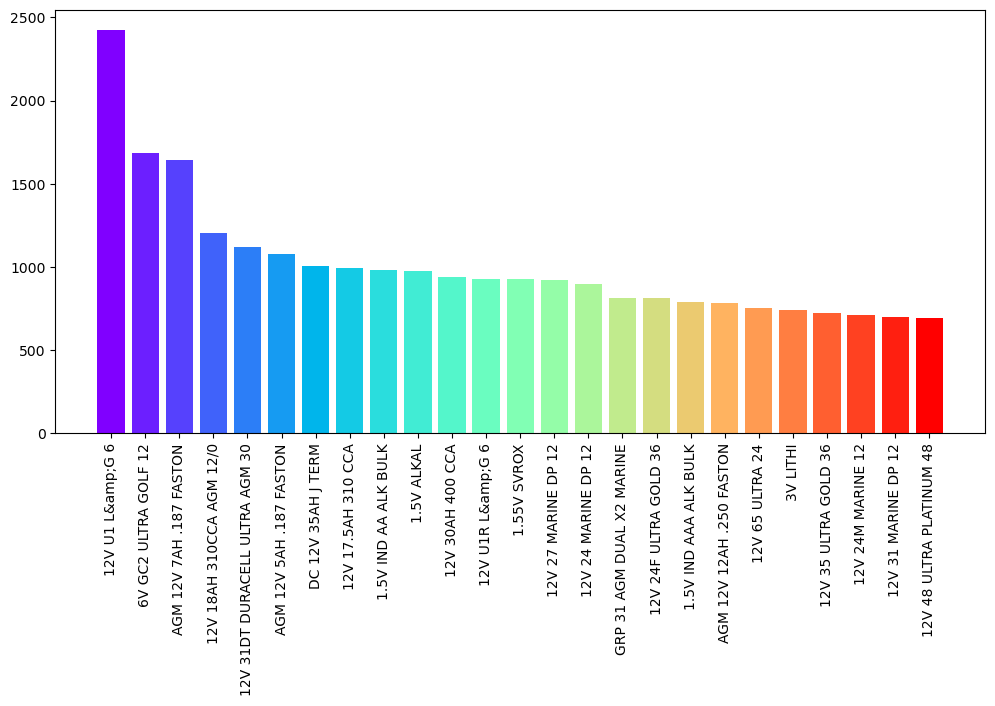

In [63]:
plt.figure(figsize=(12,5.5))
plt.xticks(rotation=90)

# Create a standard matplotlib bar plot instead
plt.bar(x.index, x.values, color=list(cm.rainbow(np.linspace(0, 1, len(x)))))

In [69]:
basket_plus = (df.groupby(['Transaction ID', 'Product'])['Unique Purchases']
.sum().unstack().reset_index().fillna(0).set_index('Transaction ID'))
basket_plus

Product,(4)F32T8 CENTIUM IS UNV,(not set),1 BANK 10A ONBOARD BATTERY CHARGER,1 BANK 5A ONBOARD BATTERY CHARGER,1.2V 1100MAH NICAD,1.2V 12000MAH NIMH,1.2V 1200MAH NICAD,1.2V 1200MAH NICAD 4/5A,1.2V 1200MAH NIMH,1.2V 1400MAH NICAD 4/5A,...,Y50-N18L-A W/METAL JACKET,YB16L-B W/METAL JACKET,YETI 1500X PORTABLE POWER STATION,YETI 200X PORTABLE POWER,YETI 3000X PORTABLE POWER STATION,YETI 400 PROTECTION CASE,YETI 500X PORTABLE POWER STATION,ZBUG LANTERN + LIGHT,ZUS SMART VEHICLE HEALTH MONITOR MINI,ZUS UNIVERSAL CAR AUDIO ADAPTER
Transaction ID,,,,,,,,,,,,,,,,,,,,,
1234,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
123456,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12345678,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
EC0032704676,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
EC0042407100,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
EC0044007291,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
EC0044007292,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
EC0044007293,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [71]:
basket_plus.drop('(not set)', axis=1, inplace=True)
basket_plus

Product,(4)F32T8 CENTIUM IS UNV,1 BANK 10A ONBOARD BATTERY CHARGER,1 BANK 5A ONBOARD BATTERY CHARGER,1.2V 1100MAH NICAD,1.2V 12000MAH NIMH,1.2V 1200MAH NICAD,1.2V 1200MAH NICAD 4/5A,1.2V 1200MAH NIMH,1.2V 1400MAH NICAD 4/5A,1.2V 1500MAH NIMH,...,Y50-N18L-A W/METAL JACKET,YB16L-B W/METAL JACKET,YETI 1500X PORTABLE POWER STATION,YETI 200X PORTABLE POWER,YETI 3000X PORTABLE POWER STATION,YETI 400 PROTECTION CASE,YETI 500X PORTABLE POWER STATION,ZBUG LANTERN + LIGHT,ZUS SMART VEHICLE HEALTH MONITOR MINI,ZUS UNIVERSAL CAR AUDIO ADAPTER
Transaction ID,,,,,,,,,,,,,,,,,,,,,
1234,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
123456,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12345678,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
EC0032704676,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
EC0042407100,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
EC0044007291,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
EC0044007292,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
EC0044007293,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [89]:
def encode_units(x):
    if x <= 0:
        return 0
    if x >= 1:
        return 1
    
basket_encode_plus = basket_plus.map(encode_units)
basket_encode_plus

Product,(4)F32T8 CENTIUM IS UNV,1 BANK 10A ONBOARD BATTERY CHARGER,1 BANK 5A ONBOARD BATTERY CHARGER,1.2V 1100MAH NICAD,1.2V 12000MAH NIMH,1.2V 1200MAH NICAD,1.2V 1200MAH NICAD 4/5A,1.2V 1200MAH NIMH,1.2V 1400MAH NICAD 4/5A,1.2V 1500MAH NIMH,...,Y50-N18L-A W/METAL JACKET,YB16L-B W/METAL JACKET,YETI 1500X PORTABLE POWER STATION,YETI 200X PORTABLE POWER,YETI 3000X PORTABLE POWER STATION,YETI 400 PROTECTION CASE,YETI 500X PORTABLE POWER STATION,ZBUG LANTERN + LIGHT,ZUS SMART VEHICLE HEALTH MONITOR MINI,ZUS UNIVERSAL CAR AUDIO ADAPTER
Transaction ID,,,,,,,,,,,,,,,,,,,,,
1234,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
123456,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12345678,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
EC0032704676,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
EC0042407100,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
EC0044007291,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
EC0044007292,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
EC0044007293,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [91]:
basket_plus.tail()

Product,(4)F32T8 CENTIUM IS UNV,1 BANK 10A ONBOARD BATTERY CHARGER,1 BANK 5A ONBOARD BATTERY CHARGER,1.2V 1100MAH NICAD,1.2V 12000MAH NIMH,1.2V 1200MAH NICAD,1.2V 1200MAH NICAD 4/5A,1.2V 1200MAH NIMH,1.2V 1400MAH NICAD 4/5A,1.2V 1500MAH NIMH,...,Y50-N18L-A W/METAL JACKET,YB16L-B W/METAL JACKET,YETI 1500X PORTABLE POWER STATION,YETI 200X PORTABLE POWER,YETI 3000X PORTABLE POWER STATION,YETI 400 PROTECTION CASE,YETI 500X PORTABLE POWER STATION,ZBUG LANTERN + LIGHT,ZUS SMART VEHICLE HEALTH MONITOR MINI,ZUS UNIVERSAL CAR AUDIO ADAPTER
Transaction ID,,,,,,,,,,,,,,,,,,,,,
EC0044007291,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
EC0044007292,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
EC0044007293,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
EC0044007294,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
EC0044007295,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Filtering The Transaction(Bought More Than 1 Items Only)

In market basket analysis, purpose is to uncover the association between 2 or more items that is bought according to historical data.
So, it is less useful if a transaction only bought a single item

In [95]:
basket_filter_plus = basket_encode_plus[(basket_encode_plus > 0).sum(axis=1) >= 2]
basket_filter_plus


Product,(4)F32T8 CENTIUM IS UNV,1 BANK 10A ONBOARD BATTERY CHARGER,1 BANK 5A ONBOARD BATTERY CHARGER,1.2V 1100MAH NICAD,1.2V 12000MAH NIMH,1.2V 1200MAH NICAD,1.2V 1200MAH NICAD 4/5A,1.2V 1200MAH NIMH,1.2V 1400MAH NICAD 4/5A,1.2V 1500MAH NIMH,...,Y50-N18L-A W/METAL JACKET,YB16L-B W/METAL JACKET,YETI 1500X PORTABLE POWER STATION,YETI 200X PORTABLE POWER,YETI 3000X PORTABLE POWER STATION,YETI 400 PROTECTION CASE,YETI 500X PORTABLE POWER STATION,ZBUG LANTERN + LIGHT,ZUS SMART VEHICLE HEALTH MONITOR MINI,ZUS UNIVERSAL CAR AUDIO ADAPTER
Transaction ID,,,,,,,,,,,,,,,,,,,,,
EC0032704676,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
EC0042801384,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
EC0042802882,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
EC0042803407,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
EC0042803469,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
EC0044007261,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
EC0044007268,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
EC0044007269,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


According to the result above, there are 6321 transaction that bought more than 1 items.
It means, (6321 % 83013) * 100 = 7.61 % of the basket data is a transaction that is bought more than 1 item.

**Algorithm**

frequent_itemsets_plus = apriori(basket_filter_plus, min_support=0.03, 
                                 use_colnames=True).sort_values('support', ascending=False).reset_index(drop=True)

frequent_itemsets_plus['length'] = frequent_itemsets_plus['itemsets'].apply(lambda x: len(x))

frequent_itemsets_plus

Results
Frequently Bought Items

In apriori algorithm, we are able to define the frequent data defined by the given support value

A frequently bought items are defined as an items that is bought as many as 3% out of the whole transaction i.e. support value 0.03
Column length that contain the number of item that is bought

There are 12 transaction that is consider as a frequently bought items

1.5V IND AA ALK BULK is the most frequently bought items with the support value of 0.115013, 
it means the item is bought = 6321 * .115013 = 727 times out of the whole transaction.

Below is the Frequently bought 1 item 

In [102]:
frequent_itemsets_plus[ (frequent_itemsets_plus['length'] == 1)]

,support,itemsets,length
0,0.115013,(1.5V IND AA ALK BULK),1
1,0.111691,(1.5V IND AAA ALK BULK),1
2,0.098719,(1.5V ALKAL),1
4,0.079418,(1.5V ALKALINE AA CONTRACTOR 24PK),1
5,0.056320,(D ALKALINE BULK),1
7,0.042240,(9V IND ALK BULK),1
8,0.037810,(24PK 1.5V AA ALKALINE),1
9,0.036228,(C ALKALINE BULK),1
11,0.030059,(1.5V ALKALINE D CONTRACTOR 12PK),1


Below is the Frequently brought 2 items together

In [107]:
frequent_itemsets_plus[ (frequent_itemsets_plus['length'] == 2)]


,support,itemsets,length
3,0.086062,"(1.5V IND AA ALK BULK, 1.5V IND AAA ALK BULK)",2
6,0.051732,"(1.5V ALKAL, 1.5V ALKALINE AA CONTRACTOR 24PK)",2
10,0.031641,"(1.5V IND AA ALK BULK, D ALKALINE BULK)",2
12,0.030059,"(D ALKALINE BULK, 1.5V IND AAA ALK BULK)",2


**From association rules, we could extract information and even discover knowledge about which items that is more effective to be sold together.**

In [112]:
rules = association_rules(frequent_itemsets_plus, metric='lift', 
                  min_threshold=1).sort_values('lift', ascending=False).reset_index(drop=True)
rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(1.5V IND AA ALK BULK),(1.5V IND AAA ALK BULK),0.115013,0.111691,0.086062,0.748281,6.699549,1.0,0.073216,3.528965,0.961298,0.611924,0.716631,0.759409
1,(1.5V IND AAA ALK BULK),(1.5V IND AA ALK BULK),0.111691,0.115013,0.086062,0.770538,6.699549,1.0,0.073216,3.856793,0.957703,0.611924,0.740717,0.759409
2,(1.5V ALKAL),(1.5V ALKALINE AA CONTRACTOR 24PK),0.098719,0.079418,0.051732,0.524038,6.598500,1.0,0.043892,1.934152,0.941382,0.409262,0.482978,0.587716
3,(1.5V ALKALINE AA CONTRACTOR 24PK),(1.5V ALKAL),0.079418,0.098719,0.051732,0.651394,6.598500,1.0,0.043892,2.585390,0.921645,0.409262,0.613211,0.587716
4,(1.5V IND AA ALK BULK),(D ALKALINE BULK),0.115013,0.056320,0.031641,0.275103,4.884627,1.0,0.025163,1.301813,0.898631,0.226501,0.231840,0.418450
5,(D ALKALINE BULK),(1.5V IND AA ALK BULK),0.056320,0.115013,0.031641,0.561798,4.884627,1.0,0.025163,2.019585,0.842739,0.226501,0.504849,0.418450
6,(D ALKALINE BULK),(1.5V IND AAA ALK BULK),0.056320,0.111691,0.030059,0.533708,4.778424,1.0,0.023768,1.905048,0.837918,0.217890,0.475079,0.401415
7,(1.5V IND AAA ALK BULK),(D ALKALINE BULK),0.111691,0.056320,0.030059,0.269122,4.778424,1.0,0.023768,1.291159,0.890148,0.217890,0.225502,0.401415


results above,

1.5V IND AA ALK BULK and 1.5V IND AAA ALK BULK are the items that has the highest association each other since these two items has the highest “lift” value. *The higher the lift value, the higher the association between the items willl. 

If the lift value is more than 1, it is enough for us to say that those two items are associated each other.

In thise case, the highest value is 6.699549 which is very high. It means these 2 items are very good to be sold together.

The support value of 1.5V IND AA ALK BULK and 1.5V IND AAA ALK BULK are 0.086062 which means there are 8.60% out of total transaction that these 2 items were sold together. 

In number, it is 6321 * 0.086062 = 544 times.

The confidence value is influenced by the antecedent and consequent.

If the antecedent is higher than the consequent, then the rule that will be applied is rule number 1 (not number 2). vice versa.

In this case, the antecedent value is higher than the consequent value. It means we will apply rule number 1 which is 1.5V IND AA ALK BULK and 1.5V IND AAA ALK BULK.

It means that a customer will tends to bought 1.5V IND AAA ALK BULK, AFTER they bought 1.5V IND AA ALK BULK.

This could be a very valuable information, We could give a discounts on 1.5V IND AAA ALK BULK if a customer buy 1.5V IND AA ALK BULK.

***Demonstration to increase sell of one item through another item***

In [129]:
basket_plus['1.5V IND AAA ALK BULK'].sum()


806.0

In [131]:
basket_plus['1.5V IND AA ALK BULK'].sum()

1022.0

We sell 1022 quantity of 1.5V IND AA ALK BULK but only 806 quantity of 1.5V IND AAA ALK BULK
so maybe we can drive more 1.5V IND AAA ALK BULK sales through recommendations.

**or**

In [137]:
basket_plus['1.5V ALKAL'].sum()

1163.0

In [139]:
basket_plus['1.5V ALKALINE AA CONTRACTOR 24PK'].sum()

715.0

We sell 1163 quantity of 1.5V ALKAL but only 715 quantity of 1.5V ALKALINE AA CONTRACTOR 24PK
so maybe we can drive more 1.5V ALKALINE AA CONTRACTOR 24PK sales through recommendations.

**Conclusion**

Market Basket analysis is done using Apriori Algorithm and Association Rules
Recommendation is provided for Upselling and Cross Selling through giving ideas of Item Placements, Product Bundling and Applying Discounts
Rules are visualized through 3D Scatter Plot and Network Graph

**Data Analysis Key Findings**

>Outlier Handling: Winsorizing was applied to the 'Product Revenue' column to mitigate the influence of extreme values, using the 1st and 99th percentiles as bounds.

>Data Cleaning: The 'Product Category (Enhanced Ecommerce)' column was cleaned by converting text to lowercase and standardizing some category names (e.g., 'batteries' to 'battery').

>Strong Item Association: "1.5V IND AAA ALK BULK" and "1.5V IND AA ALK BULK" exhibit a very high lift of 58.46, suggesting a strong positive association between their purchases.

>Frequent Itemsets: The analysis identified frequent itemsets using min_support=0.005. Top 10 frequent item combinations were visualized.

>Association Rules: Association rules were generated based on lift with a min_threshold=0.5. Top rules were identified and visualized.

**Insights or Next Steps**

>Product Bundling: Consider bundling "1.5V IND AAA ALK BULK" and "1.5V IND AA ALK BULK" together as a promotional offer, given their strong positive association. This could potentially increase sales and revenue.

>Targeted Promotions: Further investigate other frequent itemsets and association rules to identify additional opportunities for targeted promotions and product recommendations. Investigate the association rules with lower lift values to see if there are other interesting, but less obvious relationships.